# Module 2 — Handling Text Data

Series: 
> Build a Large Language Model From the Inside Out Companion to blog post: [How Does an LLM Read "Abeg, My Transfer Never Enter"?](https://academy.confamnode.com/blog/how-does-an-llm-read-abeg-my-transfer)


## 2.1 Install packages

In [1]:
!pip install -q torch --index-url https://download.pytorch.org/whl/cpu 
!pip install -q tiktoken numpy

Check packages' versions

In [2]:
from importlib.metadata import version

print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))
print("numpy version:", version("numpy"))

torch version: 2.14.0+cpu
tiktoken version: 0.14.0
numpy version: 2.5.3


Packages' versions used at the time of creating this notebook

- `torch` -> `2.14.0+cpu`
- `tiktoken` -> `0.14.0`
- `numpy` -> `2.5.3`

## 2.2 What are embeddings?

Deep neural network models including LLMs, cannot process raw text directly because neural networks perform mathematical operations on numbers. Text such as:
```text
- Lagos
- Transfer
- Doctor
- Network
```
is categorical/discrete data.

The neural network needs numerical representation, so we need:
```text
word/token -> number/vector
```
That's an **embedding**.

An **embedding** converts discrete data, such as a token, into a numerical vector that an LLM can work with. It maps an object to a point in a continuous vector space.

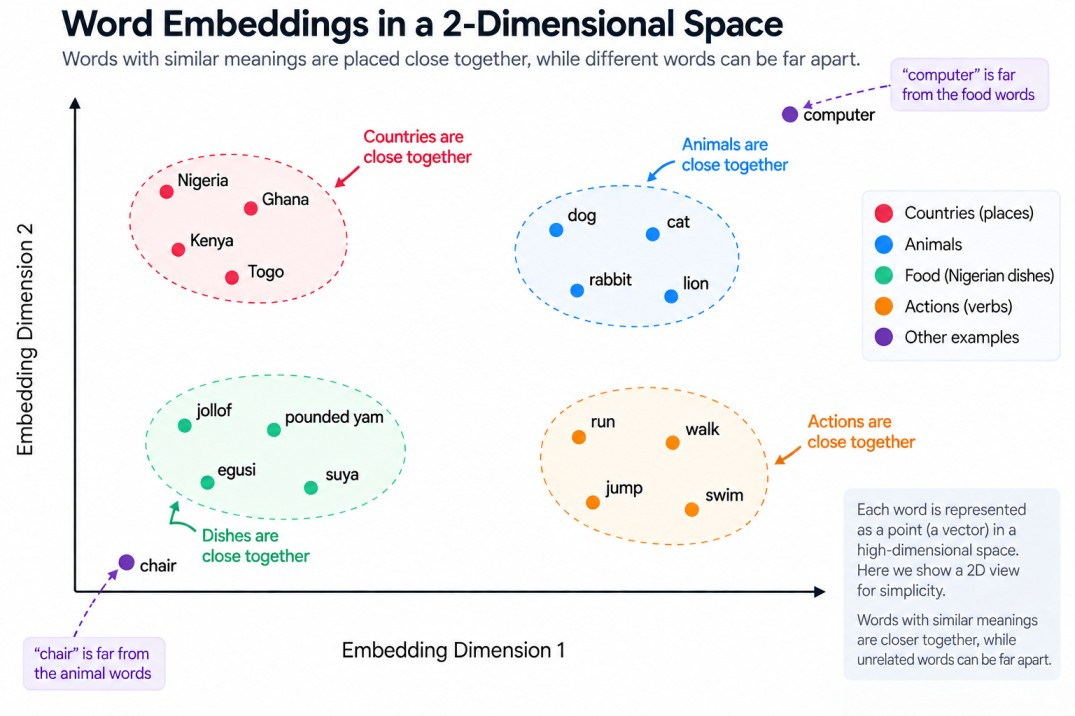

## 2.3 Tokenizing text

Tokenizing text is the preprocessing step we perform to create embeddings to be used by a large language model. Here we will take raw text and split it into smaller units called tokens. The tokens include individual words, and special characters such as punctuation marks.

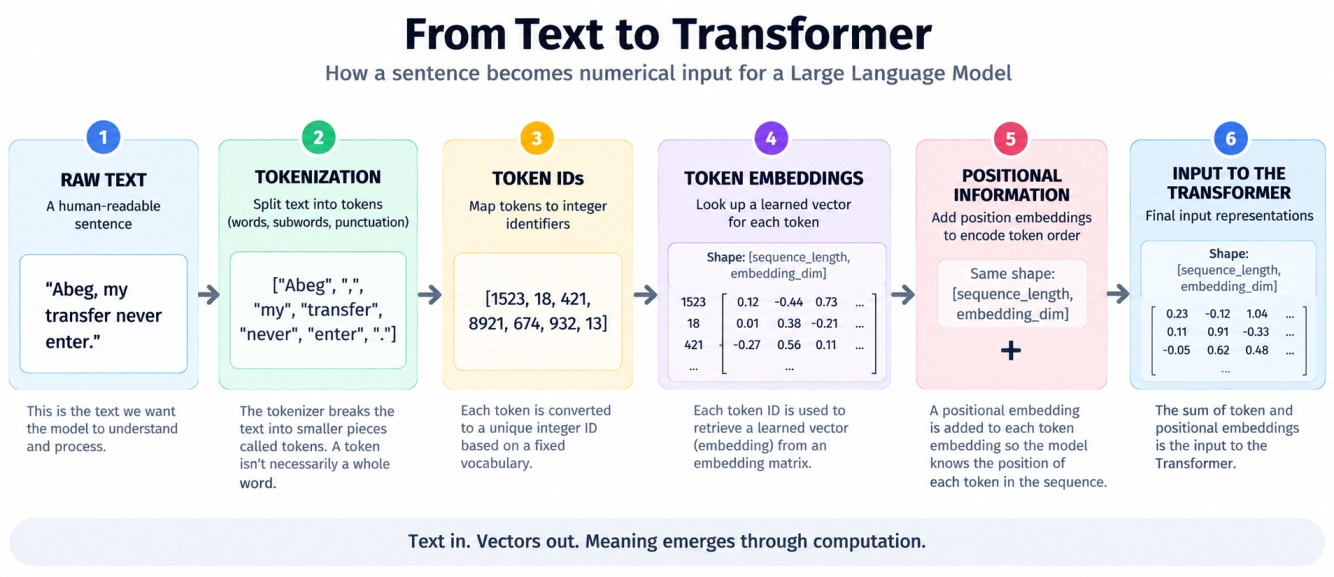

### Download the file

Source text: 
> **[The Woman with Two Skins](https://www.gutenberg.org/cache/epub/34655/pg34655-images.html#III)**

Story III from [Folk Stories from Southern Nigeria, West Africa by Elphinstone Dayrell](https://www.gutenberg.org/ebooks/34655). It is a public domain traditional folktale written in the early 20th century.

In [3]:
import os
import requests

url = "https://raw.githubusercontent.com/confamnode-academy/build-llm-from-the-inside-out/main/mod02/the-woman-with-two-skins.txt"
fp = "the-woman-with-two-skins.txt"

if not os.path.exists(fp):    
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    with open(fp, "wb") as f:
        f.write(response.content)

### Load the file

In [4]:
with open(fp, "r", encoding="utf-8") as f:
  raw_txt = f.read()
    
print(f"Total number of characters: {len(raw_txt)}\n")
print(f"Raw text:\n{raw_txt[:150]}")

Total number of characters: 13582

Raw text:
The Woman with Two Skins

Eyamba I. of Calabar was a very powerful king. He fought and conquered all the surrounding countries, killing all the old me


### Split the text

Let's use regular expression to split on whitespaces. Firstly, we will test it

In [5]:
import re

text = "Abeg, my transfer never enter. First, make we test am."
result = re.split(r'(\s)', text)
print(result)

['Abeg,', ' ', 'my', ' ', 'transfer', ' ', 'never', ' ', 'enter.', ' ', 'First,', ' ', 'make', ' ', 'we', ' ', 'test', ' ', 'am.']


We will now modify the regular expression to also split on special characters such as punctuation marks (periods and commas)

In [6]:
result = re.split(r'([,.]|\s)', text)
print(result)

['Abeg', ',', '', ' ', 'my', ' ', 'transfer', ' ', 'never', ' ', 'enter', '.', '', ' ', 'First', ',', '', ' ', 'make', ' ', 'we', ' ', 'test', ' ', 'am', '.', '']


Let's remove the empty strings

In [7]:
result = [
    item for item in result
    if item.strip() # Remove whitespace from string. Also check if item is a string or just whitespace. Filter out of it's just a whitespace
] 
print(result)

['Abeg', ',', 'my', 'transfer', 'never', 'enter', '.', 'First', ',', 'make', 'we', 'test', 'am', '.']


We need to handle other kinds of special characters (question mark, dash, parenthesis, etc.)

In [8]:
text = "Abeg, my transfer never enter. Na wa oh ! We still _ dey test am?"
result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
result = [
    item.strip() for item in result
    if item.strip() # Remove whitespace from string. Also check if item is a string or just whitespace. Filter out of it's just a whitespace
] 
print(result)

['Abeg', ',', 'my', 'transfer', 'never', 'enter', '.', 'Na', 'wa', 'oh', '!', 'We', 'still', '_', 'dey', 'test', 'am', '?']


Let's apply this tokenization to the raw text

In [9]:
raw_tokens = re.split(r'([,.:;?_!"()\']|--|\s)', raw_txt)
raw_tokens = [
    raw_token.strip() for raw_token in raw_tokens
    if raw_token.strip() # Remove whitespace from string. Also check if item is a string or just whitespace. Filter out of it's just a whitespace
]
print(f"Total number of tokens: {len(raw_tokens)}\n")
print(f"Raw tokens:\n{raw_tokens[:50]}")

Total number of tokens: 3034

Raw tokens:
['The', 'Woman', 'with', 'Two', 'Skins', 'Eyamba', 'I', '.', 'of', 'Calabar', 'was', 'a', 'very', 'powerful', 'king', '.', 'He', 'fought', 'and', 'conquered', 'all', 'the', 'surrounding', 'countries', ',', 'killing', 'all', 'the', 'old', 'men', 'and', 'women', ',', 'but', 'the', 'able-bodied', 'men', 'and', 'girls', 'he', 'caught', 'and', 'brought', 'back', 'as', 'slaves', ',', 'and', 'they', 'worked']


## 2.4 Convert tokens to token IDs

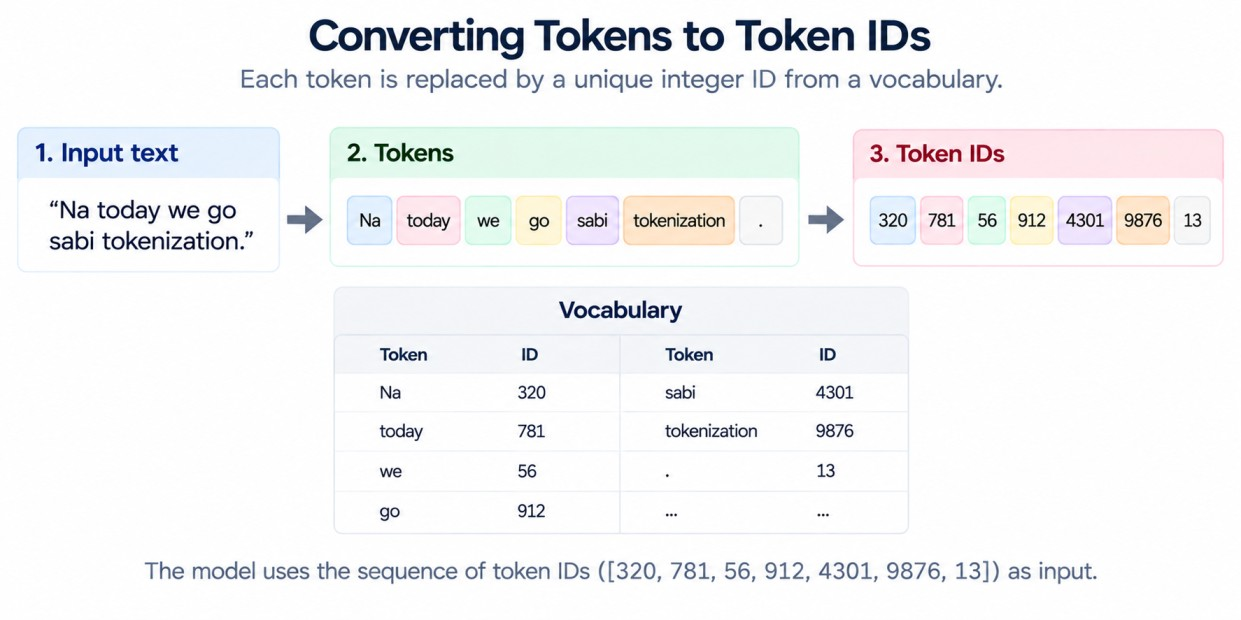

### Create a list of all unique tokens and sort them

We can use the tokens to build a vocabulary of unique tokens

In [10]:
unique_tokens = sorted(set(raw_tokens))
vocab_size = len(unique_tokens)
print(vocab_size)

594


### Create a vocabulary

In [11]:
vocab = {tok:_id for _id,tok in enumerate(unique_tokens)}
for i, pair in enumerate(vocab.items()):
    print(pair)
    if i >= 50:
        break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('Adiaha', 11)
('After', 12)
('All', 13)
('Am', 14)
('And', 15)
('As', 16)
('But', 17)
('Calabar', 18)
('Directly', 19)
('Egbo', 20)
('Egbos', 21)
('Every', 22)
('Eyamba', 23)
('For', 24)
('He', 25)
('Her', 26)
('His', 27)
('However', 28)
('I', 29)
('If', 30)
('Immediately', 31)
('In', 32)
('Is', 33)
('It', 34)
('Ju', 35)
('Now', 36)
('On', 37)
('One', 38)
('She', 39)
('Skins', 40)
('So', 41)
('That', 42)
('The', 43)
('Then', 44)
('They', 45)
('This', 46)
('To', 47)
('Two', 48)
('Water', 49)
('When', 50)


### Implementing a basic text tokenizer

In [12]:
class BasicTokenizerV1:
    def __init__(self, vocab):
        self.token_to_id = vocab # keep the vocab dict itself, used by encode()
        self.id_to_token = {_id:tok for tok, _id in vocab.items()} # flip it so decode() can go ID -> token

    def encode(self, text): # turn raw text to a list of token IDs
        raw_tokens = re.split(r'([,.?_!"()\']|--|\s)', text)
        raw_tokens = [
            tok.strip() for tok in raw_tokens if tok.strip()
        ]
        token_ids = [self.token_to_id[tok] for tok in raw_tokens]
        return token_ids
    
    def decode(self, token_ids):  # turn a list of token IDs back into readable text
        text = " ".join([self.id_to_token[tid] for tid in token_ids])
    
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)  # strip the stray space before punctuation
        return text

- `Encode` - Encode is turning tokens into integer IDs. `Encode` = converting text into token IDs.
- `Decode` - Decode is turning integer IDs into tokens. It is the reverse of the `encode` process.

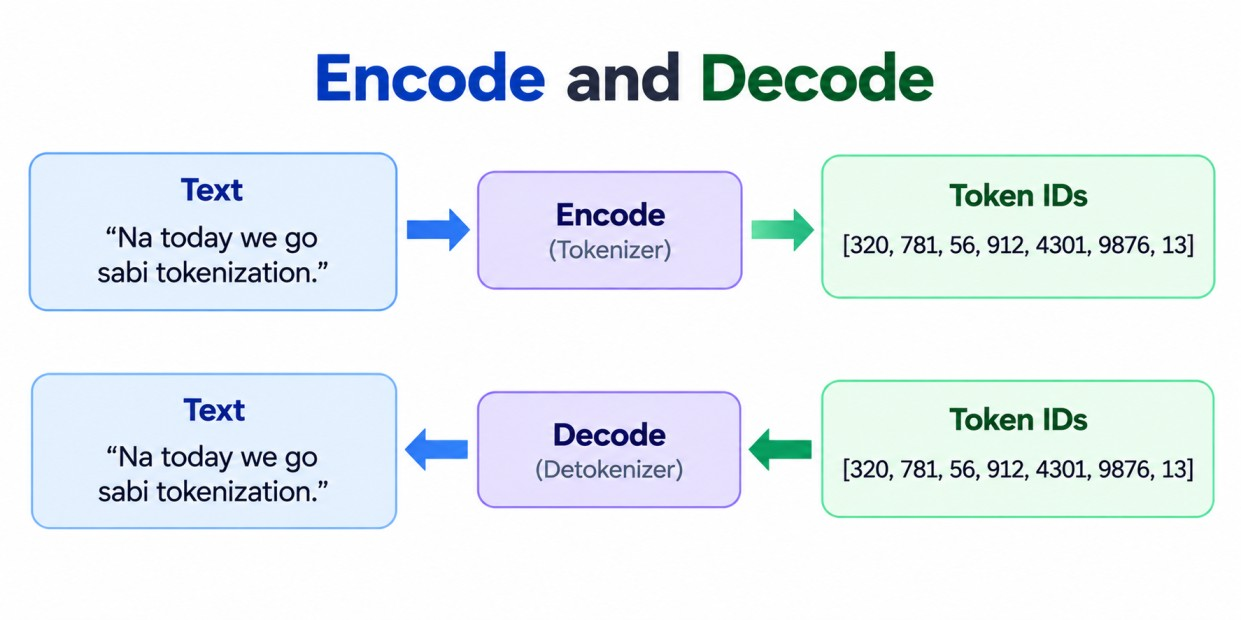

### Instantiate the `BasicTokenizerV1`

In [13]:
tokenizer = BasicTokenizerV1(vocab)
txt = """Then the head wife went again to the
        Ju Ju man and got more medicine, which made 
        the king forget Adiaha for three years, 
        during which time she was in mourning for her son."""
token_ids = tokenizer.encode(txt)
print(token_ids)

[44, 508, 264, 572, 561, 68, 528, 508, 35, 35, 335, 80, 247, 352, 344, 5, 567, 332, 508, 303, 226, 11, 224, 519, 591, 5, 191, 567, 526, 463, 553, 286, 357, 224, 269, 477, 7]


### Turn the token IDs back into text

In [14]:
print(tokenizer.decode(token_ids))

Then the head wife went again to the Ju Ju man and got more medicine, which made the king forget Adiaha for three years, during which time she was in mourning for her son.


## 2.5 Adding special context tokens

What if the LLM encounters a token that was not in our vocabulary? Let's try and see:

In [15]:
tokenizer = BasicTokenizerV1(vocab)
txt = "Wetin dey happen for your side?"
tokenizer.encode(txt)

KeyError: 'Wetin'

As you can see we encountered a `KeyError` as our vocabulary doesn't have the token "Wetin". In this case, we use special tokens such as `<|unk|>` to denote unknown words.

Special tokens give the model information about the structure of the input. They aren't ordinary words. Examples of special tokens are:
- `<|unk|>` - This represents an unknown token. It can substitute something unknown that the tokenizer cannot represent from its vocabulary.
  - `"something_unknown"` -> `<|unk|>`.
  - The model can then process the special token rather than receiving something it has no token ID for.
- `<|endoftext|>` - This indicates the boundary/end of text. Suppose our training corpus contains several separate pieces of text (Document A, Document B, Document C). We don't necessarily want the model to interpret them as one continuous piece of prose. We can represent the boundaries as:
  -  Document A `<|endoftext|>` Document B `<|endoftext|>` Document C

These special tokens help the LLM to communicate structural information. There are other kinds of special tokens:
- `[BOS]` - beginning of sequence: Denotes the start of a sequence
- `[EOS]` - end of sequence: Denotes the end of a sequence. Good for concatenating multiple unrelated texts. Used to separate independent texts in the sequence (e.g. two different blog posts or two different lab reports, etc.). It is similar to `"<|endoftext|>"`
- `[PAD]` - padding: Used to make sure shorter texts in a batch are extended or "padded" up to the length of the length of the longest text.

In [16]:
unique_tokens = sorted(list(set(raw_tokens)))
unique_tokens.extend(["<|endoftext|>", "<|unk|>"])
vocab = {tok:idx for idx, tok in enumerate(unique_tokens)}

print(len(vocab.items()))

596


In [17]:
for i, pair in enumerate(list(vocab.items())[-5:]):
  print(pair)

('years', 591)
('you', 592)
('young', 593)
('<|endoftext|>', 594)
('<|unk|>', 595)


### Create a basic text tokenizer that handles unknown words

In [18]:
class BasicTokenizerV2:
    def __init__(self, vocab):
        self.token_to_id = vocab # keep the vocab dict itself, used by encode()
        self.id_to_token = {idx:tok for tok, idx in vocab.items()} # flip it so decode() can go ID -> token

    def encode(self, text): # turn raw text to a list of token IDs
        raw_tokens = re.split(r'([,.?_!"()\']|--|\s)', text)
        raw_tokens = [
            tok.strip() for tok in raw_tokens if tok.strip()
        ]
        raw_tokens = [
            tok if tok in self.token_to_id
            else "<|unk|>" for tok in raw_tokens # Use unknown word indicator (<|unk|>) if token does not exist in our vocabulary
        ]
        token_ids = [self.token_to_id[tok] for tok in raw_tokens]
        return token_ids
    
    def decode(self, token_ids):  # turn a list of token IDs back into readable text
        text = " ".join([self.id_to_token[tid] for tid in token_ids])
    
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)  # strip the stray space before punctuation
        return text

### Use `BasicTokenizerV2`

In [19]:
txt1 = "Wetin be the name of that place?"
txt2 = "I would like to order jollof."
txt = " <|endoftext|> ".join((txt1, txt2))
print(txt)

Wetin be the name of that place? <|endoftext|> I would like to order jollof.


Tokenize the sample text using the `BasicTokenizerV2` on the vocab

In [20]:
tokenizer = BasicTokenizerV2(vocab)
print(f"Encoded tokens:\n{tokenizer.encode(txt)}\n")
print(f"Decoded tokens:\n{tokenizer.decode(tokenizer.encode(txt))}")

Encoded tokens:
[595, 102, 508, 361, 373, 507, 403, 10, 594, 29, 584, 321, 528, 385, 595, 7]

Decoded tokens:
<|unk|> be the name of that place? <|endoftext|> I would like to order <|unk|>.


## 2.6 Byte Pair Encoding (BPE)

**BPE** learns frequently occuring character/subword sequences from the training corpus. **BPE** repeatedly merges frequently occuring characters/subwords to create larger tokens. It discovers sequences of symbols occur often enough that it is useful to treat them as a single token. That's why tokens can be:
- complete words
- part of words
- punctuation
- spaces
- numbers
- symbols
- other frequently occuring sequences

### Instantiate the BPE tokenizer from tiktoken

In [21]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.name)

gpt2


Use the `encode` method similar the our `BasicTokenizerV2`:

In [22]:
txt = (
    "Wetin be the name of that place? <|endoftext|> I would like to order someunknownFood."
)
_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
print(_ids)

[54, 316, 259, 307, 262, 1438, 286, 326, 1295, 30, 220, 50256, 314, 561, 588, 284, 1502, 617, 34680, 24602, 13]


Convert the token IDs back into text using the `decode` method similar to our `BasicTokenizerV2`:

In [23]:
strs = tokenizer.decode(_ids)

print(strs)

Wetin be the name of that place? <|endoftext|> I would like to order someunknownFood.


### Example

Let's give the tiktoken library BPE tokenizer a try by using unknown word like *"Odogwu Parara"* and inspect the token IDs.

In [24]:
unk_words = "Odogwu Parara"
token_ids = tokenizer.encode(unk_words)
print(token_ids)

[46, 9703, 43812, 2547, 3301]


Now create the mapping using the list of ids with the `decode` function

In [25]:
mapping = {tokenizer.decode([tid]): tid for tid in token_ids}
print(mapping)

{'O': 46, 'dog': 9703, 'wu': 43812, ' Par': 2547, 'ara': 3301}


In [26]:
og_input = tokenizer.decode(token_ids)
print(og_input)

Odogwu Parara


**Exercise** - Try and use the BPE tokenizer on any unknown words of your choice

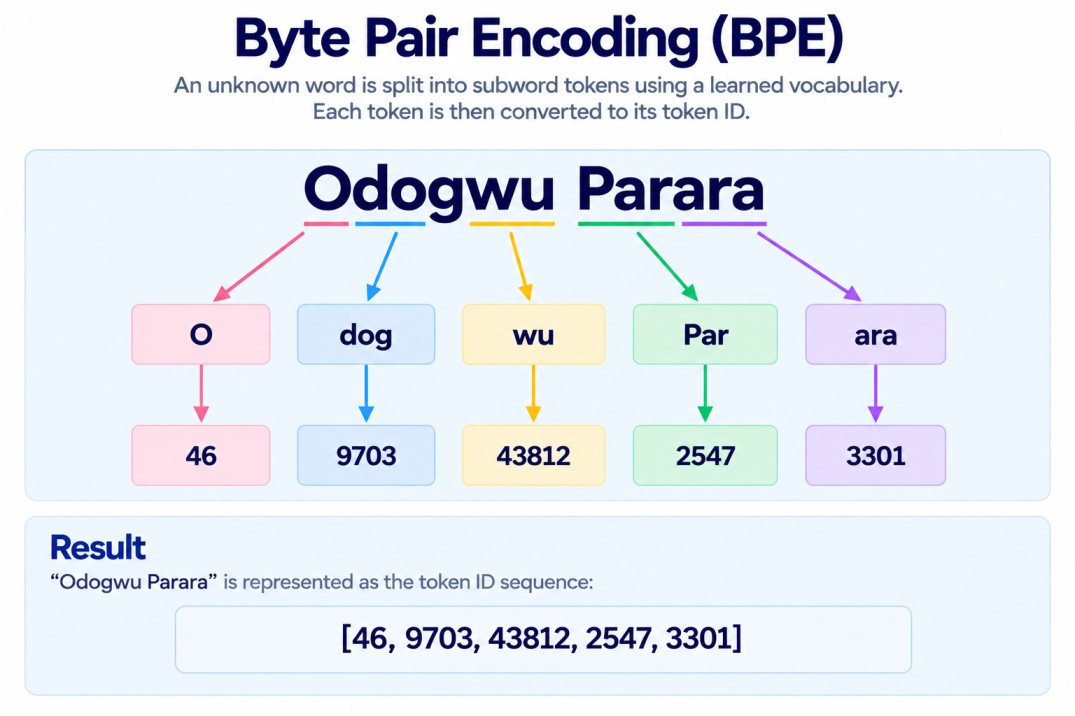

## 2.7 Data sampling with a sliding window

The sliding window sampling concept is when each target token is the next token corresponding to the input position. The window moves by *n* position at a time. That's why it's called a sliding window.

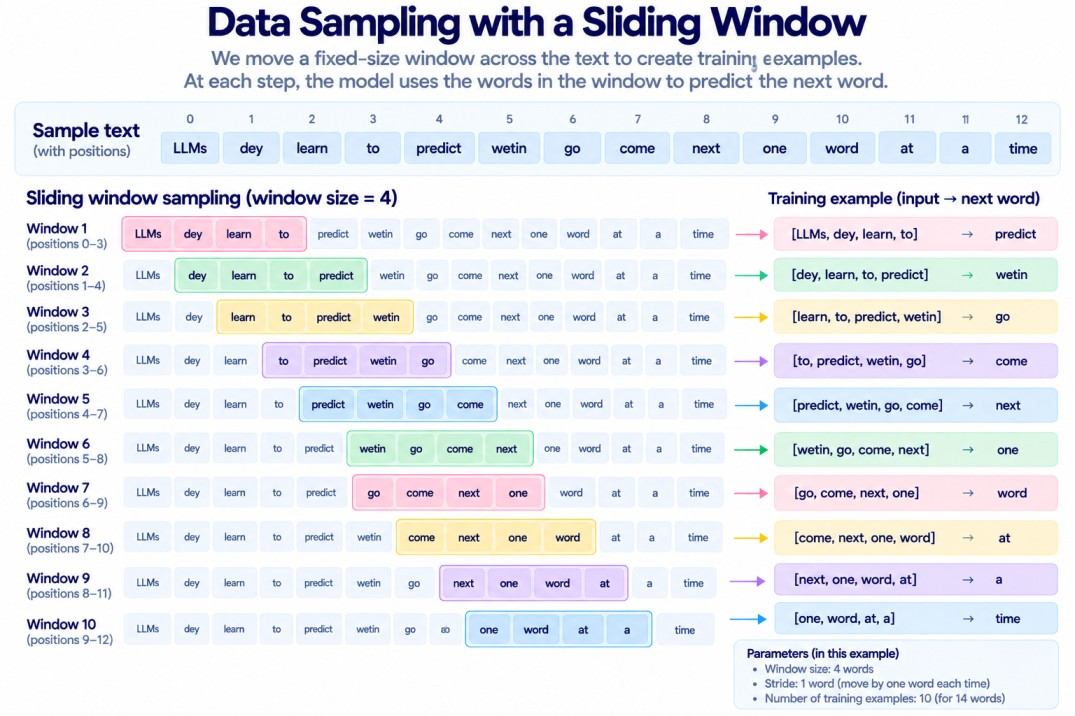

In [27]:
with open(fp, "r", encoding="utf-8") as f:
    raw_txt = f.read()

encoded_txt = tokenizer.encode(raw_txt)
print(len(encoded_txt))

3121


Here we will get the inputs and targets for each text chunk. For the model to predict the next word, each target token is the next token corresponding to the input position.

In [28]:
encoded_sample = encoded_txt[100:]
print(encoded_sample[:10])

[12479, 530, 286, 262, 19230, 338, 14850, 11, 355, 484]


In [29]:
ctx_size = 4
_input = encoded_sample[:ctx_size]
next_word = encoded_sample[1:ctx_size+1]
print(f"Input: {_input}") 
print(f"Next word:       {next_word}")

Input: [12479, 530, 286, 262]
Next word:       [530, 286, 262, 19230]


This is how it will look as the model predicts one word at a time

In [30]:
for i in range(1, ctx_size+1):
    _input = encoded_sample[:i]
    next_word = encoded_sample[i]
    print(_input, "---->", next_word)

[12479] ----> 530
[12479, 530] ----> 286
[12479, 530, 286] ----> 262
[12479, 530, 286, 262] ----> 19230


In [31]:
for i in range(1, ctx_size+1):
    _input = tokenizer.decode(encoded_sample[:i])
    next_word = tokenizer.decode([encoded_sample[i]])
    print(_input, "---->", next_word)

 marry ---->  one
 marry one ---->  of
 marry one of ---->  the
 marry one of the ---->  spider


### A dataset for batched inputs and targets

In [32]:
import torch
from torch.utils.data import Dataset, DataLoader

class FolkStoryDataset(Dataset):
    """
    Chunks the "The Woman with Two Skins" folk story into overlapping sequences of max_length using a sliding window.
    """
    def __init__(self, txt, tokenizer, max_length, stride): 
        self.input_ids = []
        self.next_word_ids = []

        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"}) # Encode the text
        assert len(token_ids) > max_length, "Please make sure the tokenized inputs are not less than the max_length+1"

        # Chunks the folk story into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i: i + max_length]
            next_word_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.next_word_ids.append(torch.tensor(next_word_chunk))

    # Returns the total number of input ids
    def __len__(self):
        return len(self.input_ids)

    # Returns a single data example
    def __getitem__(self, idx):
        return self.input_ids[idx], self.next_word_ids[idx]

### A data loader to generate batches with input targets pairs

In [33]:
def create_folkstory_dataloader(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2") # Initializes the tokenizer
    dataset = FolkStoryDataset(txt, tokenizer, max_length, stride) # Creates the dataset
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last, # drop_last=true drops the last batch if it is shorter tham the specified batch_size to prevent loss spikes during training
        num_workers=num_workers # The number of CPU processes to use for preprocessing
    )

    return dataloader

We can now test the dataloader with a context size of 4 and batch size 1

In [34]:
with open(fp, "r", encoding="utf-8") as f:
    raw_txt = f.read()

folkstory_dataloader = create_folkstory_dataloader(
    txt=raw_txt,
    batch_size=1,
    max_length=4,
    stride=1,
    shuffle=False
)
data_iterator = iter(folkstory_dataloader)  # Converts dataloader into a Python iterator to fetch the next entry via Python's built-in next() function

# Inspect the first and second batch
batch1 = next(data_iterator)
print("Batch 1:", batch1)
batch2 = next(data_iterator)
print("Batch 2:", batch2)

Batch 1: [tensor([[  464, 14381,   351,  4930]]), tensor([[14381,   351,  4930,  3661]])]
Batch 2: [tensor([[14381,   351,  4930,  3661]]), tensor([[ 351, 4930, 3661, 1040]])]


**Exercise** - Test the dataloader with different strides and context sizes. Examples like `max_length=2` and `stride=2`, `max_length=8` and `stride=2`, or any other combination of your choice.

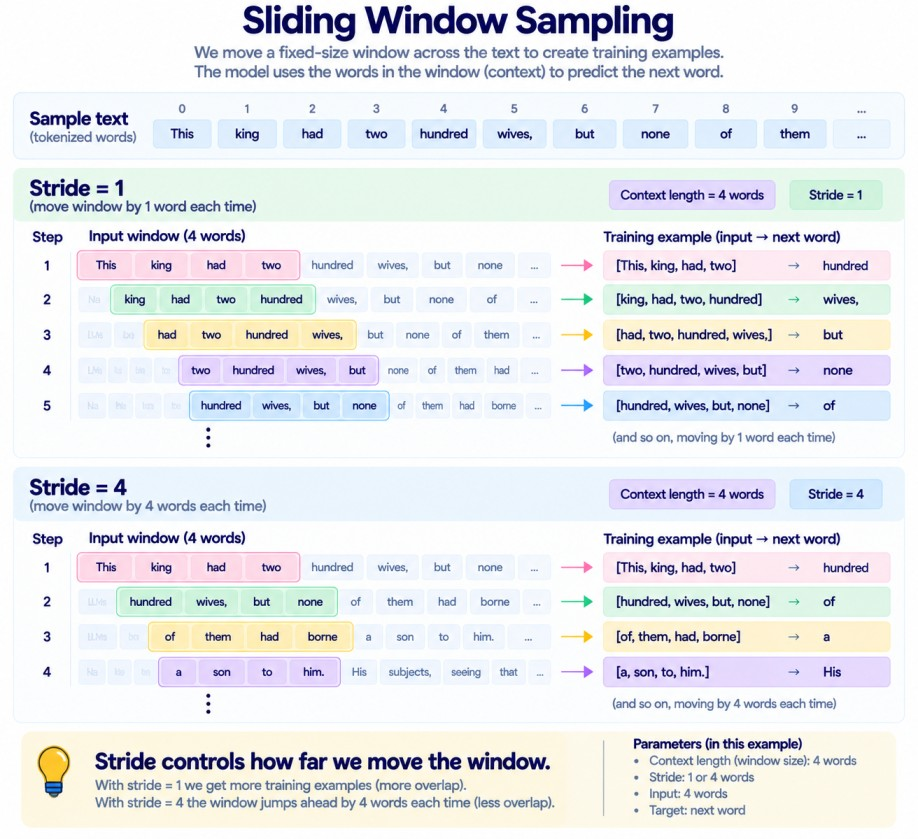

Let's try with a batch size of 8, max length 4, and stride 4. This is to avoid overlaps between batches, as overlap could lead to increased overfitting.

In [35]:
folkstory_dataloader = create_folkstory_dataloader(
    txt=raw_txt,
    batch_size=8,
    max_length=4,
    stride=4,
    shuffle=False
)
data_iterator = iter(folkstory_dataloader)  # Converts dataloader into a Python iterator to fetch the next entry via Python's built-in next() function
inputs, next_words = next(data_iterator)
print(f"Inputs:\n {inputs}\n")
print(f"Next words:\n {next_words}")

Inputs:
 tensor([[  464, 14381,   351,  4930],
        [ 3661,  1040,   198,   198],
        [36287, 31842,   314,    13],
        [  286,  2199,   397,   283],
        [  373,   257,   845,  3665],
        [ 5822,    13,   679,  8350],
        [  290, 29346,   477,   262],
        [ 7346,  2678,    11,  5170]])

Next words:
 tensor([[14381,   351,  4930,  3661],
        [ 1040,   198,   198, 36287],
        [31842,   314,    13,   286],
        [ 2199,   397,   283,   373],
        [  257,   845,  3665,  5822],
        [   13,   679,  8350,   290],
        [29346,   477,   262,  7346],
        [ 2678,    11,  5170,   477]])
